In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/AI learning/AI Engineering /Module 3 - Machine Learning/Assignment/Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [2]:
df.shape
df.info()
df.isnull().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# **1.EDA**

**1. Dataset shape**

In [3]:
df.shape

(300153, 12)

**2. Statistical summary**

In [4]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


**3. Unique values**

In [5]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Unnamed: 0 : 300153
airline : 6
flight : 1561
source_city : 6
departure_time : 6
stops : 3
arrival_time : 6
destination_city : 6
class : 2
duration : 476
days_left : 49
price : 12157


**4. Target variable (price) distribution**

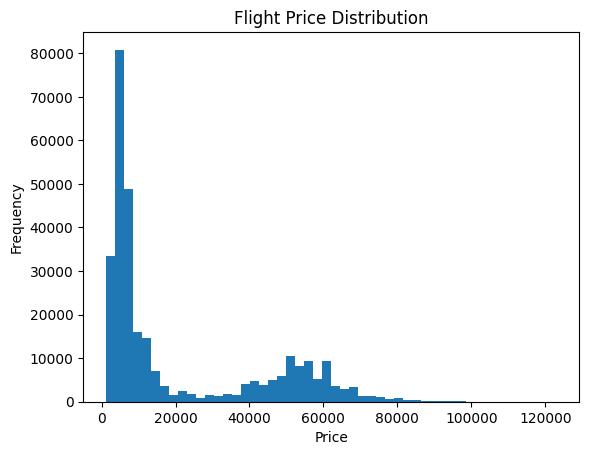

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Flight Price Distribution')
plt.show()

**5. Correlation (numerical features only)**

In [7]:
df[['duration', 'days_left', 'price']].corr()

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


**6. Average price by airline**

In [8]:
df.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


**7. Average price by class**

In [9]:
df.groupby('class')['price'].mean()

,price
class,
Business,52540.081124
Economy,6572.342383


**8. Average price by stops**

In [10]:
df.groupby('stops')['price'].mean()

,price
stops,
one,22900.992482
two_or_more,14113.450775
zero,9375.938535


# **2.Data Cleaning**

**Step 1: Drop unnecessary column**

In [11]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [12]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


**Step 2: Check unique values**

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print('----------------')

airline
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
----------------
flight
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
----------------
source_city
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
----------------
departure_time
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
----------------
stops
['zero' 'one' 'two_or_more']
----------------
arrival_time
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
----------------
destination_city
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
----------------
class
['Economy' 'Business']
----------------
duration
[ 2.17  2.33  2.25  2.08 12.25 16.33 11.75 14.5  15.67  3.75  2.5   5.83
  8.    6.   14.67 16.17 18.   23.17 24.17  8.83  4.5  15.25 11.   19.08
 22.83 26.42 17.75 19.58 26.67 15.17 20.83 11.42 22.25 26.   21.75  3.83
  4.42  7.67  8.33 10.42 23.75 19.5   6.5  12.42 21.08 28.17 28.25  9.25
 17.92  7.08 13.83  7.58 15.83

In [14]:
df.nunique()

,0
airline,6
flight,1561
source_city,6
departure_time,6
stops,3
arrival_time,6
destination_city,6
class,2
duration,476
days_left,49


In [15]:
df['flight'].nunique()

1561

In [16]:
df.drop(columns=['flight'], inplace=True)

**One-Hot Encoding**

In [17]:
df = pd.get_dummies(df, drop_first=True)

df.head()


,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,5953,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,True
1,2.33,1,5953,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,True
2,2.17,1,5956,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True
3,2.25,1,5955,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,True
4,2.33,1,5955,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,True


In [18]:
df.shape

(300153, 31)

In [19]:
df = df.astype(int, errors='ignore')

In [20]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# **3.Data Splitting**

**Step 1: Features and Target**

In [21]:
X = df.drop('price', axis=1)
y = df['price']

**Step 2: Train-Test Split**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Step 3: Verify**

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(240122, 30)
(60031, 30)
(240122,)
(60031,)


# **4.Model Training**

# ==========================
# Linear Regression
# ==========================

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# **5.Evaluation**

**Step 1: Prediction**

In [25]:
y_pred = model.predict(X_test)

**Step 2: Evaluation Metrics**

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE : 4552.94
MSE : 45716798.15
RMSE: 6761.42
R² Score: 0.9113


**Step 3: Actual vs Predicted**

In [27]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,7366,3422.327093
1,64831,55132.092683
2,6195,10409.826327
3,60160,54919.386724
4,6578,6610.127644
5,4555,9850.556351
6,23838,48113.833505
7,3860,6495.980927
8,32230,49447.533801
9,76841,58794.811783


**Step 4: Scatter Plot**

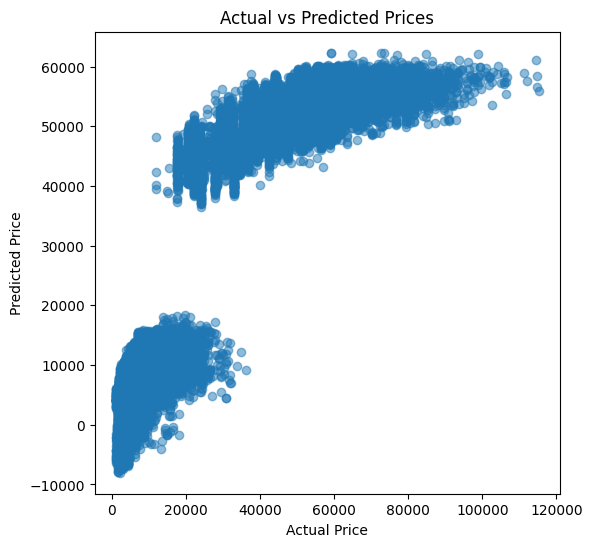

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

**Step 5: Residual Errors**

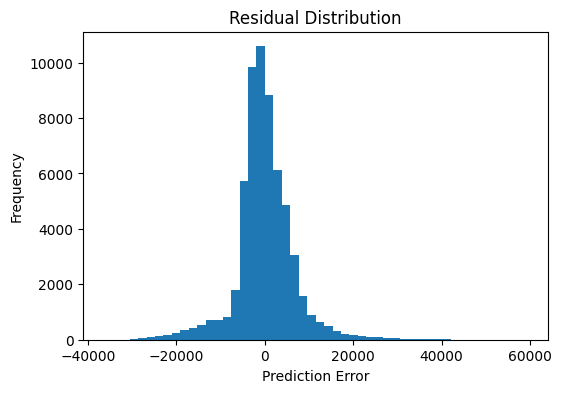

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

**Step 6: Test score**

In [30]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9114987512409962
Test R² : 0.9113125698039832


# ==========================
# Polynomial Regression
# ==========================

**Step 1: Import Libraries**

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

**Step 2: Create Polynomial Features**

In [32]:
poly = PolynomialFeatures(degree=2)


**Step 3: Transform Training Data**

In [33]:
x_train_poly = poly.fit_transform(X_train)

**Step 3: Transform Test Data**



In [34]:
x_test_poly = poly.transform(X_test)

**Step 5: Train Model**

In [35]:
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

LinearRegression()

**Step 6: Prediction**

In [36]:
y_pred_poly = poly_model.predict(x_test_poly)

**Step 7: Evaluation**

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

MAE : 4552.94
MSE : 45716798.15
RMSE: 6761.42
R² Score: 0.9113


**Step 8: Train vs Test Score**

In [38]:
train_score = poly_model.score(x_train_poly, y_train)
test_score = poly_model.score(x_test_poly, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.951483273008268
Test R² : 0.950373197157713


In [39]:
print("Original Features :", x_train_poly.shape[1])
print("Polynomial Features :", x_train_poly.shape[1])

Original Features : 496
Polynomial Features : 496


In [40]:
print(X_train.shape)
print(x_train_poly.shape)


(240122, 30)
(240122, 496)


In [41]:
y_pred_poly = poly_model.predict(x_test_poly)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("R² :", r2_score(y_test, y_pred_poly))


MAE : 3230.7258834239224
RMSE: 5057.839178848645
R² : 0.950373197157713


# ==========================
# Decision Tree Regressor
# ==========================

**Step 1: Import Libraries**

In [42]:
from sklearn.tree import DecisionTreeRegressor


**Step 2: Create Model**

In [43]:
dt_model = DecisionTreeRegressor(random_state=42)

**Step 3: Training**

In [44]:
dt_model.fit(X_train, y_train)



DecisionTreeRegressor(random_state=42)

**Step 4: Prediction**

In [45]:
y_pred_dt = dt_model.predict(X_test)

**Step 5: Evaluation**

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 1652.60
RMSE: 4306.30
R²  : 0.9640


**Step 6: Check Overfitting**

In [47]:
train_score = dt_model.score(X_train, y_train)
test_score = dt_model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9947818023458564
Test R² : 0.9640254685825336


# **Decision Tree Hyperparameter Tuning (max_depth = 15)**

In [48]:
dt_model = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

In [49]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=15, random_state=42)

In [50]:
y_pred_dt = dt_model.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 2001.39
RMSE: 3975.79
R²  : 0.9693


In [52]:
train_score = dt_model.score(X_train, y_train)
test_score = dt_model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9752864743690434
Test R² : 0.9693356203545812


# ============================================
# Random Forest Regressor
# ============================================

**Step 1: Import Libraries**



In [53]:
from sklearn.ensemble import RandomForestRegressor

**Step 2: Create Model**


In [80]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=18,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

**Step 3: Model Training**


In [81]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=18, min_samples_leaf=3, n_estimators=50,
                      n_jobs=-1, random_state=42)

**Step 4: Prediction**

In [82]:
y_pred_rf = rf_model.predict(X_test)

**Step 5: Evaluation**

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9779303976829345
MAE: 1642.5519532982546
RMSE: 3372.9050948939807


**Step 6: Train vs Test Score**

In [58]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9931571689059988
Test R² : 0.9752497385872517


**Feature Importance**

In [59]:
importance = rf_model.feature_importances_
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
29,class_Economy,0.882277
0,duration,0.051853
1,days_left,0.020652
6,airline_Vistara,0.005451
2,airline_Air_India,0.004920
8,source_city_Delhi,0.003922
25,destination_city_Delhi,0.003749
11,source_city_Mumbai,0.002505
28,destination_city_Mumbai,0.002340
10,source_city_Kolkata,0.002061


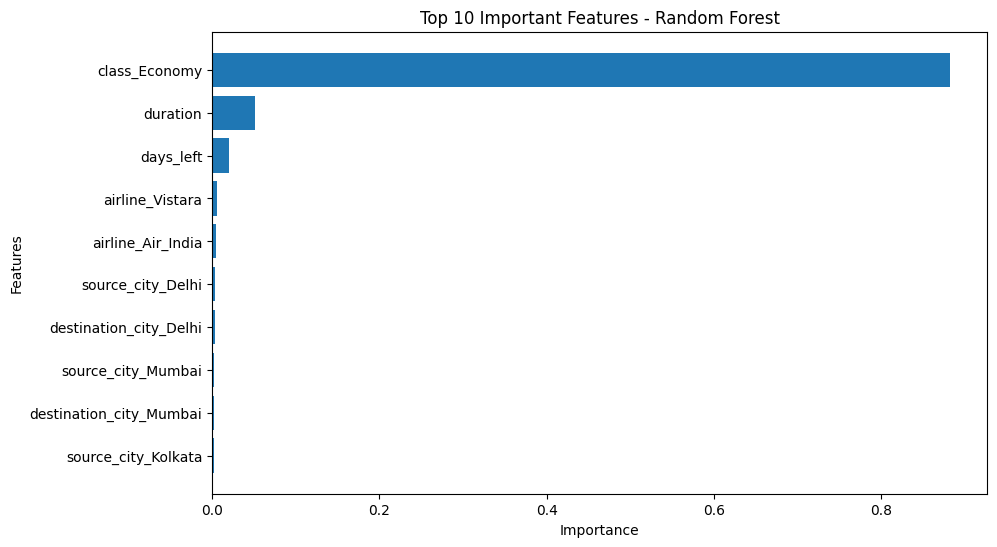

In [60]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

# **Final Model Comparison**

In [61]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        4552.94,
        3230.73,
        2001.39,
        1507.77
    ],
    'RMSE': [
        6761.42,
        5057.84,
        3975.79,
        3571.88
    ],
    'R2 Score': [
        0.9113,
        0.9504,
        0.9693,
        0.9752
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4552.94,6761.42,0.9113
1,Polynomial Regression,3230.73,5057.84,0.9504
2,Decision Tree,2001.39,3975.79,0.9693
3,Random Forest,1507.77,3571.88,0.9752


# **Save Best Model**

In [84]:
import joblib

joblib.dump(
    rf_model,
    "flight_price_model.joblib"
)

['flight_price_model.joblib']

In [85]:
import os

size_mb = os.path.getsize(
    "flight_price_model.joblib"
) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 88.18 MB


# **Save Feature Names**

In [64]:
feature_names = X_train.columns
joblib.dump(feature_names, "feature_names.joblib")

['feature_names.joblib']